## Simulating the 2D Time-Dependent Schrödinger Equation (TDSE)

#### Rafał Głodek, Antoni Krzak, Michał Sapijaszko

---

### **Project overview**

In this project, we simulate the two-dimensional time-dependent Schrödinger equation for a quantum wave packet evolving in different potential landscapes. The main goal is to visualize characteristic quantum phenomena such as wave-packet spreading, diffraction through a single slit, interference in a double-slit geometry, and finite-barrier tunnelling. The simulations are performed in natural units and the quantity visualized throughout the notebook is the probability density $|\psi(x,y,t)|^2$. By combining theoretical background, numerical methods, and animated results, the notebook demonstrates how wave-like behavior emerges from the Schrödinger evolution of a quantum state.

### Imports

In [ ]:
import numpy as np
from scipy.fft import fft2, ifft2
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display

---

## I. Theoretical background

### **Wave–particle duality**

Classical physics offers two disjoint vocabularies: *particles*, described by a position and a momentum, and obeying Newton's equations, and *waves*, described by a field obeying a linear wave equation and capable of interference. However, the experiments of the early twentieth century brought these two together. Light, long modelled as an electromagnetic wave, was shown by Einstein to be absorbed and emitted in discrete quanta of energy $E = h\nu = \hbar\omega$ [5]. Conversely, de Broglie proposed that a particle of momentum $p$ carries a wavelength $\lambda = h/p$, i.e. $p = \hbar k$ [6], a prediction confirmed when Davisson and Germer diffracted electrons off a nickel crystal [8]. Neither object is purely a particle or purely a wave.

No other experiment proves this as conclusively as the **double-slit experiment** [4]. Particles fired one at a time through two slits arrive at the screen as individual, localized detections &mdash; yet the *distribution* of those detections, accumulated over many particles, is an interference pattern: alternating high- and low-probability fringes that cannot be reproduced by adding two independent single-slit distributions. The interference is therefore a property of the *probability* of arrival, not of any classical trajectory. To describe it we need an object that 
- is wave-like and superposable, so that contributions can interfere, and 
- yields a probability distribution for where the particle is found. 

### **The wavefunction and the Born rule**

The state of the particle is a complex-valued function $\psi(\mathbf{r}, t) \in L^2(\mathbb{R}^2)$. It is not directly observable &mdash; its physical content is fixed by the **Born rule** [7], which interprets the squared modulus as a probability density on $\mathbb{R}^2$:

$$
dP = |\psi(\mathbf{r},t)|^2 \, d^2r, \qquad \int_{\mathbb{R}^2} |\psi(\mathbf{r},t)|^2 \, d^2r  = 1 .
$$

So $|\psi|^2$ is an ordinary probability density function and the normalization is simply the statement $\|\psi\|_{L^2} = 1$.

The essential point for what follows is that $\psi$ is **complex**: it carries an amplitude and a phase. Because the evolution law (next section) is linear, two contributions to the state add as complex numbers before the modulus is taken, $|\psi_1 + \psi_2|^2 = |\psi_1|^2 + |\psi_2|^2 + 2\,\mathrm{Re}(\psi_1^*\psi_2)$. The cross term is the interference term, where the two phases align it is positive (a bright fringe), where they oppose it is negative (a dark fringe). Interference is thus a direct consequence of linearity plus a complex state, and not an extra postulate [1].


### **The Schrödinger equation as the linear PDE**

We need an evolution law for $\psi$. Rather than presenting the **time-dependent Schrödinger equation (TDSE)** as a postulate to be accepted, we can characterize it in a way familiar from the theory of linear PDEs: *it is the simplest linear, first-order-in-time equation whose plane-wave solutions reproduce the quantum dispersion relation* [1, 2].

Take the plane-wave ansatz $\psi = \exp[\,i(\mathbf{k}\cdot\mathbf{r} - \omega t)\,]$. The two empirical inputs $p = \hbar k$ [6] and $E = \hbar\omega$ [5], combined with the non-relativistic energy-momentum relation $E = p^2/2m$, fix the dispersion relation.

$$
\omega(\mathbf{k}) = \frac{\hbar\, k^2}{2m}, \qquad k^2 = k_x^2 + k_y^2 .
$$

We want a constant-coefficient PDE solved by every such plane wave. Differentiating the ansatz once in time pulls down $-i\omega$, and the Laplacian pulls down $-k^2$; imposing $\hbar\omega = \hbar^2 k^2/2m$ on these gives

$$
i\hbar\,\frac{\partial \psi}{\partial t} = -\frac{\hbar^2}{2m}\,\nabla^2 \psi .
$$

Adding a position-dependent potential $V(\mathbf{r})$ to the classical energy, $E = p^2/2m + V$, promotes the right-hand side to the full Hamiltonian and yields the TDSE [1]:

$$
\boxed{\;
i\hbar\,\frac{\partial \psi}{\partial t}
= \hat H \psi
= \left( -\frac{\hbar^{2}}{2m}\,\nabla^{2} + V(\mathbf{r}) \right)\psi
\;}
$$

Two structural facts matter for both the physics and the numerics [2]. First, in Fourier space the operator $-i\nabla$ acts as multiplication by $\mathbf{k}$, so the kinetic term $\hat T = -\tfrac{\hbar^2}{2m}\nabla^2$ is diagonal there, while $V(\mathbf{r})$ is diagonal in real space, which is useful for numerical method we've chosen. Second, the evolution operator $U(t) = e^{-i\hat H t/\hbar}$ is unitary, which means that $\|\psi(t)\|_{L^2} = \|\psi(0)\|_{L^2}$ for all $t$. Finally, the equation is linear, so superpositions of solutions are solutions. This is the mathematical root of the interference described in section 2.

For our 2D problem $\nabla^2 = \partial_x^2 + \partial_y^2$ and $\psi = \psi(x,y,t)$. Following standard practice for wave-packet propagation [3] we use natural units $\hbar = 1,\ m = 1$, which removes the physical constants from the arithmetic and leaves us with the equation actually integrated by the code,

$$
i\,\frac{\partial \psi}{\partial t}
= \left( -\tfrac{1}{2}\nabla^{2} + V(x,y) \right)\psi,
\qquad \omega(\mathbf{k}) = \tfrac{1}{2}k^2 .
$$

### **Encoding the apparatus in the potential $V(x,y)$**

All scenarios share the evolution law and differ only in $V(x,y)$, which plays the role of the apparatus:

- **Free propagation** ($V \equiv 0$): the baseline, a packet that merely drifts and disperses.
- **Double slit**: a wall across the packet's path with $V$ set numerically huge ($\sim 10^{6}$, an effectively impenetrable barrier), pierced by two narrow gaps where $V = 0$. Where $V \gg E$ the equation forces $\psi \approx 0$, so amplitude can only emerge through the slits. The two emerging beams overlap and interfere.
- **Tunnelling barrier**: a finite rectangular region of height $V_0$ and thickness $d$, with the packet's energy deliberately chosen as $E < V_0$. For an ideal one-dimensional barrier, a classical particle with energy $E<V_0$ would be reflected. In our two-dimensional finite-barrier simulation, the measured probability beyond the obstacle should be interpreted with care, because lateral spreading around the finite barrier may also contribute.

### **The Gaussian wave packet, dispersion, and the uncertainty relation**

A single plane wave has constant modulus, hence $|\psi|^2$ is not integrable over $\mathbb{R}^2$: it is not in $L^2$ and cannot represent a localized particle. A localized state is instead a superposition of plane waves, and the natural choice is the Gaussian wave packet &mdash; which, as noted below, is the extremal case of the Fourier uncertainty inequality. Our initial state is

$$
\psi(x,y,0) = A \,
\exp\!\left( -\frac{(x-x_0)^2 + (y-y_0)^2}{2\sigma^2} \right)
\exp\!\big( i\,k_0\, y \big).
$$

The real Gaussian envelope localizes the particle near $(x_0,y_0)$ with width set by $\sigma$. The phase factor $e^{ik_0 y}$ supplies a mean momentum
$\langle p_y\rangle = \hbar k_0$, launching the packet in $+y$ [1].

**Why it moves, and why it spreads &mdash; a dispersive-PDE argument [3].** 

Take the spatial Fourier transform of the free equation. Each mode $\hat\psi(\mathbf{k},t)$ evolves independently as $\hat\psi(\mathbf{k},t) = \hat\psi(\mathbf{k},0)\, e^{-i\omega(\mathbf{k})t}$, so the solution is the inverse transform

$$
\psi(\mathbf{r},t) = \frac{1}{(2\pi)^2}\int \hat\psi(\mathbf{k},0)\,
e^{\,i(\mathbf{k}\cdot\mathbf{r} - \omega(\mathbf{k})t)}\, d^2k .
$$

For a packet whose spectrum is concentrated near $\mathbf{k}_0$, the method of stationary phase locates the bump where the phase is stationary,
$\nabla_{\mathbf{k}}(\mathbf{k}\cdot\mathbf{r} - \omega t) = 0$, i.e. at $\mathbf{r} = (\nabla_{\mathbf{k}}\omega)\,t$. The envelope therefore travels at the group velocity

$$
v_\text{g} = \frac{d\omega}{dk}\bigg|_{k_0} = \frac{\hbar k_0}{m}
\;\xrightarrow{\;\hbar=m=1\;}\; k_0 ,
$$

while the individual crests move at the phase velocity $v_\text{p} = \omega/k = \hbar k_0/2m = v_\text{g}/2$. Crucially, $\omega(k) = \hbar k^2/2m$ is nonlinear in $k$: different spectral components advance at different speeds and gradually dephase, so the packet spreads, on a time scale $\tau \sim m\sigma^2/\hbar$ (order $\sigma^2$ in natural units). Contrast this with the classical wave equation, whose $\omega \propto k$ is linear and which therefore translates wave packets without spreading.

### **Quantum tunnelling as a sign change in a linear ODE**

Tunnelling is most transparent through ordinary differential equations. Seek a stationary state of fixed energy $E$, $\psi(\mathbf{r},t) = u(\mathbf{r})\, e^{-iEt/\hbar}$. Substitution turns the TDSE into the time-independent equation $\hat H u = E u$. In one dimension, in a region of constant potential $V$, this is a constant-coefficient linear ODE [1]:

$$
-\frac{\hbar^2}{2m}\,u'' + V u = E u
\quad\Longleftrightarrow\quad
u'' = \frac{2m\,(V - E)}{\hbar^2}\, u \;=\; c\,u .
$$

Everything hinges on the sign of $c$, exactly as in elementary ODE theory. Where $E > V$ (classically allowed), $c < 0$ and the solutions are oscillatory, $u \propto e^{\pm i k x}$ with $k = \sqrt{2m(E-V)}/\hbar$, thus we get propagating waves. Where $E < V$ (classically forbidden), $c > 0$ and the solutions are real exponentials,

$$
u \propto e^{\pm \kappa x}, \qquad
\kappa = \frac{\sqrt{2m\,(V - E)}}{\hbar}
\;\xrightarrow{\;\hbar=m=1\;}\; \sqrt{2\,(V_0 - E)} .
$$

Inside a classically forbidden region the state does not vanish. The physical (decaying) branch falls off smoothly and exponentially. Such a non-propagating, exponentially decaying solution is called evanescent [1].

For a barrier of finite thickness $d$, the evanescent tail has not decayed to zero at the far edge, so a nonzero amplitude emerges and resumes propagating as an oscillatory wave on the other side: the particle has tunneled. Quantitatively, matching $u$ and $u'$ across the two interfaces is a linear boundary-value problem (a transfer-matrix calculation); in the thick-barrier limit $\kappa d \gg 1$ the transmission probability is dominated by the exponential [1],

$$
T \;\approx\; 16\,\frac{E}{V_0}\!\left(1 - \frac{E}{V_0}\right) e^{-2\kappa d}
\;\sim\; e^{-2\kappa d},
$$

so $T$ is exponentially sensitive to the thickness $d$ and to $\sqrt{V_0 - E}$. This is what we'll observe in numerical solutions: integrating the Born density over the region beyond the barrier,

$$
T(t) = \int_{-\infty}^{\infty}\!\!\int_{y_\text{end}}^{\infty}
|\psi(x,y,t)|^2 \, dy\,dx ,
$$

returns the probability that the particle has crossed — identically zero in classical mechanics, yet visibly nonzero in the simulation.

---

## II. Numerical Method and Implementation

Before choosing the final numerical scheme, several possible approaches to solving the time-dependent Schrödinger equation can be considered. One common option is a **finite-difference method**, where the spatial derivatives in the Laplacian are replaced by difference formulas on the grid. **Explicit finite-difference** schemes are relatively simple to implement, but for Schrödinger-type evolution they usually require very small time steps to remain stable and accurate. A more robust finite-difference approach is the **Crank-Nicolson method**, which treats time evolution implicitly and is well known for its stability and good conservation properties. Its main disadvantage in two dimensions is computational cost, because each time step requires solving a large system of linear equations.

Another possible family of methods is based on spectral approximations. **Chebyshev methods**, for example, approximate the action of the time-evolution operator $e^{-iHt}$ using an expansion in Chebyshev polynomials. These methods can be very accurate and stable, especially for long-time propagation, but they require careful scaling of the Hamiltonian spectrum and are somewhat more complex to implement. **Krylov** or **Lanczos methods** follow a related idea: instead of applying the full exponential operator directly, they approximate the evolution in a smaller subspace generated from the Hamiltonian and the current wavefunction. These methods are powerful for large sparse Hamiltonians, but they add extra algorithmic overhead.

In this project, we choose the **Split-Operator Fourier Transform method** because it fits the structure of our problem particularly well. The potential part of the Hamiltonian is simple in real space, while the kinetic part is simple in Fourier space. By switching between these two representations with FFTs, SOFT avoids solving large linear systems and remains efficient for a two-dimensional wave-packet simulation. This makes it a practical and natural choice for visualizing spreading, diffraction, interference, and tunnelling in our setup. For these reasons, it is also the most widely used methods for this type of time-dependent quantum wave-packet problem.

### **Discretized grid**

Our first step in the numerical solution of the Time-Dependent Schrödinger Equation is the implementation of the `Grid` class. It is responsible for creating the numerical space in which we solve our PDE. Since a computer cannot solve the equation directly on a continuous domain, we replace the physical space with a discrete approximation.

The class initializes two grids: a spatial grid and a momentum-space grid. The spatial grid is centered around the point $(0,0)$ and consists of `nx` $\times$ `ny` points, with spacings `dx` and `dy` in the respective directions. It is used to store the positions of physical objects in the simulation, such as the wave packets, barriers, and slits.

The second grid represents the corresponding Fourier-space coordinates. It is constructed using the frequencies associated with the Fast Fourier Transform and multiplied by $2\pi$ to obtain angular wave numbers. This grid is important for the Split-Operator Fourier Transform method used later, because the kinetic part of the Schrödinger equation is evaluated efficiently in momentum space.

In [ ]:
class Grid:
    def __init__(self, nx, ny, dx, dy):
        """
        Initializes the 2D spatial and momentum grids.
        nx, ny: Number of grid points (should be powers of 2 for optimal FFT speed).
        dx, dy: Spatial step size.
        """
        self.nx, self.ny = nx, ny
        self.dx, self.dy = dx, dy

        # Real space grid (centered at 0,0)
        x = np.arange(-nx/2, nx/2) * dx
        y = np.arange(-ny/2, ny/2) * dy
        self.X, self.Y = np.meshgrid(x, y)

        # Momentum space grid (reciprocal space for FFT)
        kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
        ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi
        self.KX, self.KY = np.meshgrid(kx, ky)

### **Potentials**

After defining the numerical grid, our next step is constructing the potential function `V(x,y)`. In the Schrödinger equation, this potential dictates how the wave packet interacts with its environment by mapping out obstacles like walls and slits, while regions of zero potential represent free space without any barriers. This landscape is generated using the `create_potential` function, which returns a two-dimensional array matching the spatial grid's size and offers a choice between **four** distinct simulation scenarios.

The first two scenarios (`"single_slit"` and `"double_slit"`) are grouped together as they both generate high-potential walls. In the single-slit case, the opening is placed precisely in the middle of the wall, whereas the double-slit setup places two openings at an equal distance from the center. Aside from these slits, the constructed wall is effectively impenetrable. We can also manipulate specific arguments of this potential, including its `wall_height` (`V0`), `wall_thickness`, `wall_y` (placement), and `slit_width`, as well as the `slit_separation` for the double-slit configuration.

Another option is the `"tunneling"` scenario. Instead of an almost infinite wall, this generates a finite barrier. Similarly to the slit scenarios, it features strictly adjustable parameters: `barrier_height` (`V0`), `barrier_thickness`, `barrier_width`, and `barrier_y`. This setup is used to study quantum tunneling, where a wave packet with a lower energy than the barrier potential may still have a nonzero probability of transmitting to the other side.

Finally, the function includes a `"free"` scenario, where no potential is applied, allowing the wave packet to evolve unobstructed. This serves as a useful baseline to verify how the packet naturally disperses without interacting with any obstacles. The resulting array `V` is later used by the propagator in the Split-Operator Fourier Transform method to advance the wave function in time.

In [ ]:
def create_potential(grid, p_type="double_slit", V0=None, **params):
    """
    Generates V(x, y) for the simulation scenarios.

    Scenarios:
    - "double_slit" / "slit": hard wall with two open slits.
    - "single_slit": hard wall with one open slit.
    - "tunnelling" / "barrier": finite rectangular barrier with E < V0.
    - "free": no obstacle, useful as a baseline.
    """
    V = np.zeros((grid.ny, grid.nx), dtype=float)
    scenario = p_type.lower()

    if scenario in ("double_slit", "slit", "single_slit"):
        wall_height = 1e6 if V0 is None else V0
        wall_thickness = params.get("wall_thickness", 0.6)
        slit_width = params.get("slit_width", 0.8)
        slit_separation = params.get("slit_separation", 3.0)
        wall_y = params.get("wall_y", 0.0)

        wall_mask = np.abs(grid.Y - wall_y) <= wall_thickness / 2
        V[wall_mask] = wall_height

        if scenario == "single_slit":
            open_mask = np.abs(grid.X) <= slit_width / 2
        else:
            upper_slit = np.abs(grid.X - slit_separation / 2) <= slit_width / 2
            lower_slit = np.abs(grid.X + slit_separation / 2) <= slit_width / 2
            open_mask = upper_slit | lower_slit

        V[wall_mask & open_mask] = 0.0

    elif scenario in ("tunnelling", "tunnelling_barrier", "barrier"):
        barrier_height = 2.4 if V0 is None else V0
        barrier_thickness = params.get("barrier_thickness", 1.0)
        barrier_width = params.get("barrier_width", 7.0)
        barrier_y = params.get("barrier_y", 0.0)
        barrier_mask = (
            (np.abs(grid.Y - barrier_y) <= barrier_thickness / 2) &
            (np.abs(grid.X) <= barrier_width / 2)
        )
        V[barrier_mask] = barrier_height

    elif scenario == "free":
        pass
    else:
        raise ValueError(f"Unknown potential scenario: {p_type}")

    return V

### **Gaussian wave packet**

The `initialize_wave_packet` function defines the initial state of the quantum particle. Since the Time-Dependent Schrödinger Equation describes the evolution of a wave function, we first need to specify the wave function at time $t = 0$. In this project, the initial state is chosen to be a two-dimensional Gaussian wave packet.

The Gaussian envelope determines where the particle is initially localized in space. Its center is given by the parameters `x0` and `y0`, while the parameter `sigma` controls the width of the packet. A smaller value of `sigma` produces a more localized packet, whereas a larger value creates a wider wave packet.

The function also includes a complex phase factor, `exp(1j * k0y * grid.Y)`. This phase gives the packet an initial momentum in the positive or negative $y$-direction, depending on the sign of `k0y`. In our simulations, this is what makes the packet move toward the barrier or slit system.

The normalization factor is included so that the total probability represented by the wave function is approximately equal to one. This is important because $|\psi(x,y,t)|^2$ is interpreted as the probability density of finding the particle at a given point.

Overall, this function prepares the initial quantum state before time evolution begins. The returned array is complex-valued and has the same shape as the spatial grid, so it can be directly passed to the propagator used later in the simulation.

In [ ]:
def initialize_wave_packet(grid, x0, y0, k0y, sigma):
    """
    Creates the initial complex wavefunction psi(x,y,t=0).
    """
    # Normalization constant
    norm = 1.0 / (sigma * np.sqrt(np.pi))
    
    # Gaussian envelope (real part)
    envelope = np.exp(-((grid.X - x0)**2 + (grid.Y - y0)**2) / (2 * sigma**2))
    
    # Phase factor determining momentum (complex part)
    phase = np.exp(1j * k0y * grid.Y)
    
    return norm * envelope * phase

### **SOFT**

The core numerical method used in this project is the **Split-Operator Fourier Transform method**, abbreviated as SOFT. This method approximates the time evolution of the wave function governed by the Time-Dependent Schrödinger Equation. In our case, the equation is solved in two spatial dimensions for a quantum wave packet moving through different potential landscapes.

The Time-Dependent Schrödinger Equation can be written in the form

$$
i \frac{\partial \psi}{\partial t} = H\psi,
$$

where $\psi(x,y,t)$ is the complex-valued wave function and $H$ is the Hamiltonian operator. In our simulation, natural units are used, so $\hbar = 1$ and $m = 1$. The Hamiltonian is split into two parts:

$$
H = K + V.
$$

Here, $K$ is the kinetic energy operator and $V$ is the potential energy operator. The kinetic part contains spatial derivatives and is related to the Laplacian operator:

$$
K = -\frac{1}{2}\nabla^2.
$$

The potential part $V(x,y)$ describes the environment through which the wave packet moves. It represents barriers, walls, slits, or free space depending on the chosen scenario.

If the Hamiltonian were simple, the exact time evolution over a small time step $\Delta t$ could be written using the evolution operator

$$
\psi(t+\Delta t) = e^{-iH\Delta t}\psi(t).
$$

However, because $H = K + V$, this becomes

$$
\psi(t+\Delta t) = e^{-i(K+V)\Delta t}\psi(t).
$$

The difficulty is that the kinetic operator $K$ and the potential operator $V$ generally do not commute. This means that

$$
e^{-i(K+V)\Delta t} \neq e^{-iK\Delta t}e^{-iV\Delta t}.
$$

Therefore, we cannot simply apply the kinetic and potential effects independently without introducing an approximation. The Split-Operator method solves this problem by using a symmetric approximation called Strang splitting:

$$
\psi(t+\Delta t)
\approx
e^{-iV\Delta t/2}
e^{-iK\Delta t}
e^{-iV\Delta t/2}
\psi(t).
$$

This means that each time step is divided into three parts. First, the wave function is evolved by half a time step under the influence of the potential. Then it is evolved by a full time step under the influence of the kinetic energy. Finally, another half time step of the potential evolution is applied. This symmetric structure is important because it gives better accuracy than simply applying the full potential step followed by the full kinetic step. The split-operator Fourier method is a standard approach for time-dependent Schrödinger simulations [9], and the symmetric splitting used here is an example of Strang splitting [10].

The reason this method is efficient is that the two parts of the Hamiltonian are simple in different representations. The potential operator is simple in real space. Since $V(x,y)$ is just a function defined at every grid point, applying the potential evolution means multiplying the wave function by a phase factor:

$$
e^{-iV(x,y)\Delta t/2}.
$$

This operation is local: each value of the wave function is multiplied independently at each point of the spatial grid.

However, the kinetic operator is not that simple in real space because it contains derivatives. Directly approximating those derivatives would require a finite-difference scheme. Instead, SOFT uses the Fourier transform. In momentum space, derivatives become multiplication by wave numbers. For a Fourier mode with wave numbers $k_x$ and $k_y$, the kinetic energy becomes

$$
K = \frac{k_x^2 + k_y^2}{2}.
$$

This is why the `Grid` class also creates the arrays `KX` and `KY`. They store the momentum-space coordinates corresponding to the spatial grid. Once the wave function is transformed into Fourier space using `fft2`, the kinetic evolution can be applied by simple multiplication:

$$
e^{-iK\Delta t}
=
e^{-i(k_x^2+k_y^2)\Delta t/2}.
$$

After this multiplication, the wave function is transformed back to real space using the inverse Fourier transform `ifft2`.

In the implementation, this full time step is performed inside the `step` method of the `Propagator` class. The code first multiplies the wave function by `V_half_step`, which corresponds to the first factor

$$
e^{-iV\Delta t/2}.
$$

Then the wave function is transformed into momentum space using `fft2`. In that representation, it is multiplied by `K_step`, which represents the kinetic evolution factor

$$
e^{-iK\Delta t}.
$$

After that, `ifft2` returns the wave function to real space. Finally, the second half-step of the potential evolution is applied by multiplying again by `V_half_step`.

The numerical sequence is therefore:

$$
\psi(x,y)
\rightarrow
e^{-iV\Delta t/2}\psi(x,y)
\rightarrow
\mathcal{F}[\psi]
\rightarrow
e^{-iK\Delta t}\mathcal{F}[\psi]
\rightarrow
\mathcal{F}^{-1}[\psi]
\rightarrow
e^{-iV\Delta t/2}\psi(x,y).
$$

This procedure is repeated many times to simulate the full time evolution of the quantum system.

An important feature of the method is that, when no absorbing boundaries or hard-wall masks are applied, the split-operator evolution is approximately unitary. This means that the total probability of the wave function is preserved. Physically, this is important because the particle must exist somewhere in the domain, so the integral of $|\psi(x,y,t)|^2$ over all space should remain equal to one.

In our simulation, additional numerical treatments are also used. For hard-wall slit experiments, regions corresponding to impenetrable walls are masked so that the wave function is set to zero there. This represents the fact that the particle cannot exist inside an infinitely high potential barrier. The code also uses an absorbing rim near the edges of the grid. This is needed because FFT-based methods naturally assume periodic boundaries, meaning that a wave leaving one side of the grid could artificially reappear on the opposite side. The absorber reduces these unwanted reflections and wrap-around effects.

The SOFT method is especially well suited for this project because we simulate wave packets in two dimensions. A fully finite-difference implicit method such as Crank-Nicolson would require solving a large system of equations at every time step. In contrast, SOFT replaces the difficult derivative calculation with fast Fourier transforms, which are highly optimized in scientific Python libraries. As a result, the method is both accurate and computationally efficient for observing diffraction, interference, and tunneling.

In summary, the Split-Operator Fourier Transform method works by separating the Hamiltonian into potential and kinetic parts, applying each part in the representation where it is easiest to compute, and alternating between real space and momentum space using FFT. The potential effects are handled directly on the spatial grid, while the kinetic spreading of the wave packet is handled in Fourier space. Repeating this process over many small time steps gives the numerical time evolution of the wave function.

In [ ]:
class Propagator:
    def __init__(self, grid, V, dt, hard_wall_mask=None, absorber_width=18, absorber_strength=0.015):
        """
        Initializes the split-operator evolution matrices.
        Optional masks make hard obstacles absorbing and reduce FFT wrap-around.
        """
        self.dt = dt
        self.hard_wall_mask = hard_wall_mask

        # Half-step potential operator. Natural units: hbar = 1, m = 1.
        self.V_half_step = np.exp(-0.5j * V * dt)

        # Full-step kinetic operator in momentum space: K = (kx^2 + ky^2) / 2m.
        K = (grid.KX**2 + grid.KY**2) / 2.0
        self.K_step = np.exp(-1j * K * dt)
        self.absorber = self._make_absorber(grid, absorber_width, absorber_strength)

    def _make_absorber(self, grid, width, strength):
        """Cosine-like absorbing rim to suppress periodic FFT boundary echoes."""
        if width <= 0 or strength <= 0:
            return np.ones((grid.ny, grid.nx))

        ix = np.minimum(np.arange(grid.nx), np.arange(grid.nx)[::-1])
        iy = np.minimum(np.arange(grid.ny), np.arange(grid.ny)[::-1])
        edge_distance = np.minimum.outer(iy, ix)
        rim = np.clip((width - edge_distance) / width, 0.0, 1.0)
        return np.exp(-strength * rim**2)

    def step(self, psi):
        """Propagates the wavefunction psi forward by one time step dt."""
        if self.hard_wall_mask is not None:
            psi[self.hard_wall_mask] = 0.0

        psi *= self.V_half_step
        psi_k = fft2(psi)
        psi_k *= self.K_step
        psi = ifft2(psi_k)
        psi *= self.V_half_step
        psi *= self.absorber

        if self.hard_wall_mask is not None:
            psi[self.hard_wall_mask] = 0.0

        return psi

### **Measuring Probability Beyond the Barrier**

In several simulations, we track how much probability density reaches the region behind an obstacle. This is useful for the slit experiments, where it measures the transmitted probability behind the wall, and for the finite-barrier experiment, where it measures probability beyond the barrier.

The tracked quantity is obtained by integrating the probability density $|\psi(x,y,t)|^2$ over the region behind a chosen cutoff line:

$$
T(t) = \int_{-\infty}^{\infty} \int_{y_{\text{cut}}}^{\infty} |\psi(x,y,t)|^2 \,dy\,dx.
$$

Here, $y_{\text{cut}}$ denotes the position beyond the obstacle from which we start counting the transmitted part of the wave packet. In other words, $T(t)$ measures the total probability of finding the particle in the region $y>y_{\text{cut}}$.

Numerically, this integral is replaced by a sum over grid points. The function `calculate_transmission` selects all points for which `grid.Y > y_cut`, sums the probability density in that region, and multiplies the result by the area of one grid cell, `dx * dy`.

This quantity should be interpreted according to the simulated geometry. In the single-slit and double-slit experiments, it measures probability transmitted through the apertures into the region behind the wall. In the finite-barrier experiment, it measures probability beyond the obstacle. Since the tunneling barrier has finite width in the transverse $x$-direction, this value is not a strict one-dimensional tunneling coefficient. It is the total probability density detected beyond the finite barrier region.

In [ ]:
def calculate_transmission(grid, psi, y_cut=0.5):
    """Probability of finding the particle beyond a chosen y cut."""
    far_side_mask = grid.Y > y_cut
    return np.sum(np.abs(psi[far_side_mask])**2) * grid.dx * grid.dy


def calculate_region_probability(grid, psi, mask):
    """Convenience integral of |psi|^2 over any boolean region mask."""
    return np.sum(np.abs(psi[mask])**2) * grid.dx * grid.dy

---

## III. Numerical Experiments and Results

### **From Young’s Experiment to Quantum Wave Packets**

The double-slit experiment, first performed by Thomas Young in the early nineteenth century, is one of the most important demonstrations of wave behavior in physics. Its key observation is the appearance of interference fringes: alternating regions of high and low intensity that cannot be explained by a purely classical particle picture. In the context of this project, Young’s experiment serves as the historical and physical motivation for studying how a quantum wave packet evolves, splits, diffracts, and interferes.

Having introduced the time-dependent Schrödinger equation and the probabilistic interpretation of the wavefunction, we now use this framework to reconstruct Young-type experiments numerically. The optical wave in the classical experiment is replaced by a localized Gaussian wave packet, and the experimental apparatus is represented by the potential $V(x,y)$. By changing this potential, we model free propagation, a single slit, a double slit, and a finite barrier.

In each case, the quantity visualized is the probability density $|\psi(x,y,t)|^2$, which shows where the particle is more or less likely to be detected at a given time. The single-slit case demonstrates diffraction, the double-slit case demonstrates interference between two coherent transmitted parts of the wavefunction, and the finite-barrier case illustrates quantum tunnelling. In this way, the simulations connect the theoretical TDSE model with visible wave-like behavior of quantum probability amplitudes.


### **Experimental Geometry and Numerical Reconstruction**

We now describe the geometry of the double-slit experiment and explain how it is represented in the numerical simulation. The classical setup consists of a coherent source, an opaque barrier with two narrow openings, and a screen on which the interference pattern is observed. The purpose of this section is to connect the idealized physical geometry with the computational model used later in the simulations.

In the idealized Young geometry, a coherent source $S$ emits waves toward a barrier containing two openings, denoted by $S_1$ and $S_2$.

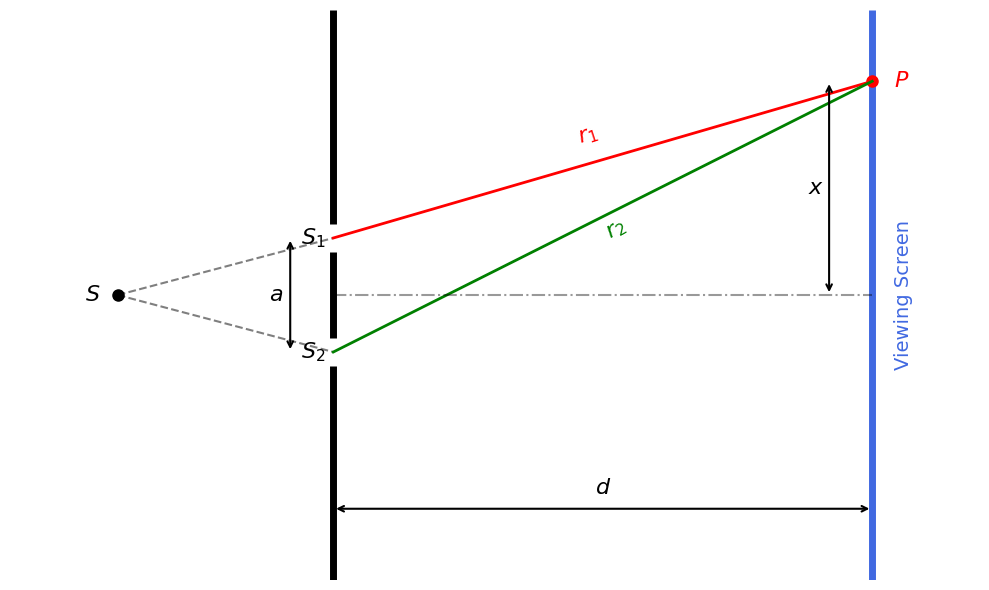

The distance between the centers of the two slits is denoted by $a$. A viewing screen is placed at a distance $d$ behind the barrier. At a given observation point $P$ on the screen, the waves arriving from the two slits have travelled different distances, denoted by $r_1$ and $r_2$. The essential quantity determining the observed interference pattern is the path length difference

$$
\Delta r = r_2 - r_1.
$$

If the screen is far from the slits compared with the slit separation, meaning $d \gg a$, the two rays travelling from the slits to the observation point are approximately parallel. Under this far-field approximation, the path length difference is approximately

$$
\Delta r \approx a\sin\theta,
$$

where $\theta$ is the angle between the central axis and the direction from the slit region to the observation point. For small angles, we may use

$$
\sin\theta \approx \tan\theta \approx \frac{x}{d},
$$

where $x$ is the transverse displacement of $P$ from the central axis. Therefore,

$$
\Delta r \approx a\frac{x}{d}.
$$

The interference pattern depends on whether the two waves arrive at a given point on the screen in phase or out of phase. Constructive interference occurs when the path length difference is an integer multiple of the wavelength:

$$
\Delta r = m\lambda,
\qquad m = 0,\pm 1,\pm 2,\ldots
$$

The corresponding approximate positions of the intensity maxima are

$$
x_m^{(\max)} \approx \frac{m\lambda d}{a}.
$$

Destructive interference occurs when the path length difference differs by half a wavelength:

$$
\Delta r = \left(m+\frac{1}{2}\right)\lambda,
\qquad m = 0,\pm 1,\pm 2,\ldots
$$

The approximate positions of the intensity minima are therefore

$$
x_m^{(\min)} \approx \frac{\left(m+\frac{1}{2}\right)\lambda d}{a}.
$$

The central maximum corresponds to the symmetric case $\Delta r=0$, where the two paths from the slits to the screen have equal length. Moving away from the center changes the path length difference and produces an alternating sequence of maxima and minima. In the quantum-mechanical interpretation, these maxima and minima do not represent deterministic particle trajectories. Instead, they correspond to regions where the probability density for detecting the particle is high or low.

These formulas are derived for an idealized monochromatic wave in the far-field regime. Our simulation is slightly different: it uses a localized Gaussian wave packet in a finite computational domain. Therefore, the formulas should be understood as qualitative predictions rather than exact numerical formulas for the simulated pattern. In the quantum case, the relevant wavelength is associated with the dominant momentum component of the wave packet, while the finite spatial width of the packet means that it contains a range of wavelengths.

In the numerical simulation, the geometry is represented on a rectangular two-dimensional grid. The wavefunction $\psi(x,y,t)$ evolves according to the time-dependent Schrödinger equation, and the plotted quantity is the probability density $|\psi(x,y,t)|^2$. The incoming quantum state is initialized as a Gaussian wave packet propagating primarily in the positive $y$-direction. The barrier is placed near $y=0$, while the transverse direction is the $x$-axis. Therefore, the slit separation is measured along $x$, and the region behind the barrier corresponds to $y>0$. This is equivalent to the textbook geometry up to a rotation of coordinates.

The potential $V(x,y)$ defines the obstacle. For the single-slit and double-slit cases, the barrier is modeled as a very high potential wall with one or two open regions. The high-potential parts act as effectively impenetrable walls, while the openings allow the wavefunction to propagate into the region behind the barrier. In the single-slit case, the transmitted packet diffracts after passing through one aperture. In the double-slit case, two transmitted parts of the same wavefunction emerge from the two openings and interfere.

The numerical analogue of the viewing screen is a horizontal observation line located behind the barrier at a fixed value $y=y_{\mathrm{screen}}$. Along this line, the detector-screen profile is defined as

$$
P_{\mathrm{screen}}(x,t)=|\psi(x,y_{\mathrm{screen}},t)|^2.
$$

This one-dimensional profile allows the numerical result to be compared with the qualitative prediction of Young’s experiment. In the double-slit case, local maxima in $P_{\mathrm{screen}}(x,t)$ correspond to constructive interference of the transmitted wavefunction, while local minima correspond to destructive interference.

This section establishes the physical geometry and the expected interference mechanism. Later, the animations and numerical plots will show how this mechanism emerges directly from the time evolution of the simulated quantum wave packet.


### **Simulation Scenarios**

After defining the experimental geometry, we now summarize the numerical scenarios considered in the project. In each case, the same general framework is used: a Gaussian wave packet is initialized on a two-dimensional grid and evolved according to the time-dependent Schrödinger equation. The main difference between the scenarios is the choice of the potential $V(x,y)$, which determines whether the packet propagates freely, interacts with slits, or encounters a finite barrier.

The purpose of considering several scenarios is to separate different physical effects. Free propagation serves as a reference case, showing how the packet evolves without obstacles. The single-slit case demonstrates diffraction, the double-slit case demonstrates interference, and the finite-barrier case demonstrates quantum tunnelling.

| Scenario         | Potential geometry                                                                               | Physical effect                             | Expected observation                                                                                                     |
| ---------------- | ------------------------------------------------------------------------------------------------ | ------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------ |
| Free propagation | No barrier, $V(x,y)=0$                                                                           | Natural spreading of a Gaussian wave packet | The packet moves mainly in the initial direction of propagation while gradually spreading in space.                      |
| Single slit      | Very high potential wall with one narrow opening                                                 | Diffraction                                 | The packet passes through one aperture and spreads strongly in the transverse direction behind the barrier.              |
| Double slit      | Very high potential wall with two narrow openings                                                | Interference                                | Two transmitted parts of the same wavefunction overlap and form alternating regions of high and low probability density. |
| Finite barrier   | Barrier with finite height, chosen so that the central packet energy is below the barrier height | Quantum tunnelling                          | A small but nonzero transmitted component appears behind a classically forbidden barrier.                                |

The main numerical parameters used in each scenario are summarized below.

| Scenario | $k_{0y}$ | $\sigma$ | Main potential parameters |
|---|---:|---:|---|
| Free propagation | $4.0$ | $1.3$ | $V(x,y)=0$ |
| Single slit | $4.5$ | $1.2$ | slit width $0.9$, wall thickness $0.6$ |
| Double slit | $4.5$ | $1.2$ | slit width $0.8$, slit separation $3.0$, wall thickness $0.6$ |
| Finite barrier | $2.0$ | $1.6$ | $V_0=2.4$, barrier thickness $1.0$, barrier width $7.0$ |

The quantity visualized in all scenarios is the probability density $|\psi(x,y,t)|^2$. For the slit experiments, the most important qualitative feature is the shape of the transmitted density behind the barrier. In the single-slit case, this density spreads due to diffraction. In the double-slit case, it forms an interference pattern. For the tunnelling case, the key quantity is the probability density that appears beyond the finite barrier, even though a classical particle with insufficient energy would be reflected.

These scenarios therefore provide a sequence of increasingly rich quantum effects. Starting from free propagation, we first observe basic wave-packet spreading, then diffraction through a single aperture, then interference between two coherent transmitted components, and finally tunnelling through a finite potential barrier.


In [ ]:
class Visualizer:
    def __init__(self, grid, V, scenario_name="Quantum Simulation", hard_wall_mask=None, clim_quantile=0.995):
        self.grid = grid
        self.V = V
        self.scenario_name = scenario_name
        self.hard_wall_mask = hard_wall_mask
        self.clim_quantile = clim_quantile

        self.fig, self.ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
        self.cmap = plt.get_cmap("magma")
        self.ax.set_aspect("equal")
        self.ax.set_xlabel("Position x (arb. units)")
        self.ax.set_ylabel("Position y (arb. units)")
        self.ax.set_title(f"2D TDSE: {scenario_name}")

        self.plot_extent = [grid.X.min(), grid.X.max(), grid.Y.min(), grid.Y.max()]

        # Use the physical array orientation directly: rows are y, columns are x.
        potential_overlay = np.ma.masked_where(V <= 0, V)
        self.ax.imshow(
            potential_overlay,
            origin="lower",
            extent=self.plot_extent,
            cmap="Greys",
            alpha=0.65,
            zorder=1,
            interpolation="nearest",
        )

        if hard_wall_mask is not None:
            self.ax.contour(
                grid.X,
                grid.Y,
                hard_wall_mask.astype(float),
                levels=[0.5],
                colors="white",
                linewidths=0.9,
                alpha=0.9,
                zorder=3,
            )

        dummy_data = np.zeros((grid.ny, grid.nx))
        self.img = self.ax.imshow(
            dummy_data,
            origin="lower",
            extent=self.plot_extent,
            cmap=self.cmap,
            zorder=2,
            interpolation="bilinear",
        )
        self.time_text = self.ax.text(
            0.02,
            0.98,
            "t = 0.00",
            transform=self.ax.transAxes,
            ha="left",
            va="top",
            color="white",
            bbox={"facecolor": "black", "alpha": 0.35, "edgecolor": "none", "pad": 3},
            zorder=4,
        )
        self.fig.colorbar(
            self.img,
            ax=self.ax,
            fraction=0.046,
            pad=0.04,
            label=r"Probability Density $|\psi(x,y,t)|^2$",
        )

    def init_plot(self, psi_0):
        prob_density_0 = np.abs(psi_0)**2
        self.img.set_array(prob_density_0)
        self.img.set_clim(0, max(np.quantile(prob_density_0, self.clim_quantile), 1e-12))
        self.time_text.set_text("t = 0.00")
        return self.img, self.time_text

    def animate(self, psi_t, current_time=0.0):
        prob_density_t = np.abs(psi_t)**2
        self.img.set_array(prob_density_t)
        # Let the scale follow the packet gently as it spreads.
        vmax = max(np.quantile(prob_density_t, self.clim_quantile), 1e-12)
        self.img.set_clim(0, vmax)
        self.time_text.set_text(f"t = {current_time:.2f}")
        return self.img, self.time_text

In [ ]:
SCENARIOS = {
    "double_slit": {
        "title": "Young Double-Slit Interference",
        "potential": {"p_type": "double_slit", "wall_thickness": 0.6, "slit_width": 0.8, "slit_separation": 3.0},
        "packet": {"x0": 0.0, "y0": -9.0, "k0y": 4.5, "sigma": 1.2},
        "hard_wall": True,
        "tracking_y": 0.5,
    },
    "single_slit": {
        "title": "Single-Slit Diffraction Control",
        "potential": {"p_type": "single_slit", "wall_thickness": 0.6, "slit_width": 0.9},
        "packet": {"x0": 0.0, "y0": -9.0, "k0y": 4.5, "sigma": 1.2},
        "hard_wall": True,
        "tracking_y": 0.5,
    },
    "tunnelling": {
        "title": "Finite Barrier Quantum tunnelling",
        "potential": {"p_type": "tunnelling", "barrier_thickness": 1.0, "barrier_width": 7.0, "V0": 2.4},
        "packet": {"x0": 0.0, "y0": -8.5, "k0y": 2.0, "sigma": 1.6},
        "hard_wall": False,
        "tracking_y": 0.5,
    },
    "free": {
        "title": "Free Gaussian Packet Baseline",
        "potential": {"p_type": "free"},
        "packet": {"x0": 0.0, "y0": -8.5, "k0y": 4.0, "sigma": 1.3},
        "hard_wall": False,
        "tracking_y": 0.5,
    },
}


def run_simulation_and_animate(scenario="double_slit", num_steps=450, dt=0.008, steps_per_frame=2):
    """
    Runs a configured TDSE scenario and returns animation plus transmission data.
    scenario can be: double_slit, single_slit, tunnelling, or free.
    """
    config = SCENARIOS.get(scenario, SCENARIOS.get(scenario.lower()))
    if config is None:
        raise ValueError(f"Unknown scenario: {scenario}. Choose from {list(SCENARIOS)}")

    grid = Grid(nx=256, ny=256, dx=0.1, dy=0.1)
    potential_kwargs = config["potential"].copy()
    p_type = potential_kwargs.pop("p_type")
    V0 = potential_kwargs.pop("V0", None)
    V = create_potential(grid, p_type=p_type, V0=V0, **potential_kwargs)

    psi = initialize_wave_packet(grid, **config["packet"])
    hard_wall_mask = V > 1e5 if config["hard_wall"] else None
    propagator = Propagator(grid, V, dt=dt, hard_wall_mask=hard_wall_mask)
    viz = Visualizer(grid, V, config["title"], hard_wall_mask=hard_wall_mask)

    time_steps = []
    transmission_data = []
    current_time = 0.0
    y_cut = config.get("tracking_y", 0.5)

    def update_frame(frame_num):
        nonlocal psi, current_time
        for _ in range(steps_per_frame):
            psi = propagator.step(psi)
            current_time += dt

        if scenario in ("tunnelling", "double_slit", "single_slit"):
            time_steps.append(current_time)
            transmission_data.append(calculate_transmission(grid, psi, y_cut=y_cut))

        return viz.animate(psi, current_time)

    anim = animation.FuncAnimation(
        viz.fig,
        update_frame,
        frames=num_steps,
        init_func=lambda: viz.init_plot(psi),
        blit=True,
        interval=20,
    )

    return anim, time_steps, transmission_data, grid, V, psi

def run_simulation_to_time(scenario="double_slit", target_time=3.5, dt=0.008):
    """Evolve a configured TDSE scenario independently up to a fixed target time."""
    config = SCENARIOS.get(scenario, SCENARIOS.get(scenario.lower()))
    if config is None:
        raise ValueError(f"Unknown scenario: {scenario}. Choose from {list(SCENARIOS)}")

    grid = Grid(nx=256, ny=256, dx=0.1, dy=0.1)
    potential_kwargs = config["potential"].copy()
    p_type = potential_kwargs.pop("p_type")
    V0 = potential_kwargs.pop("V0", None)
    V = create_potential(grid, p_type=p_type, V0=V0, **potential_kwargs)

    psi = initialize_wave_packet(grid, **config["packet"])
    hard_wall_mask = V > 1e5 if config["hard_wall"] else None
    propagator = Propagator(grid, V, dt=dt, hard_wall_mask=hard_wall_mask)

    num_steps = int(np.round(target_time / dt))
    actual_time = 0.0
    for _ in range(num_steps):
        psi = propagator.step(psi)
        actual_time += dt

    return grid, V, psi, actual_time


def plot_detector_screen_profile(grid, psi, y_screen=5.0, t=None):
    """Plot |psi|^2 along the grid row closest to the detector-screen y position."""
    y_values = grid.Y[:, 0]
    iy = np.argmin(np.abs(y_values - y_screen))
    x_values = grid.X[iy, :]
    profile = np.abs(psi[iy, :])**2
    y_actual = y_values[iy]

    plt.figure(figsize=(8, 4.5))
    plt.plot(x_values, profile, color="tab:blue", linewidth=2)
    plt.xlabel("x position")
    plt.ylabel(r"Probability density $|\psi(x,y_{\mathrm{screen}},t)|^2$")
    title = "Detector-screen profile for the double slit"
    if t is not None:
        title += f" at t = {t:.3f}"
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return x_values, profile, y_actual

def display_animation(anim):
    """Show a JS animation without Jupyter also rendering the final Matplotlib frame."""
    html = HTML(anim.to_jshtml())
    plt.close(anim._fig)
    display(html)

### **Free Propagation Baseline**

Before introducing barriers and slits, we first consider the free propagation of a Gaussian wave packet. In this baseline scenario, the potential is zero everywhere,

$$
V(x,y)=0,
$$

so the packet evolves only under the kinetic part of the time-dependent Schrödinger equation. This case provides a reference for the later simulations, where changes in the probability density can be attributed to interactions with obstacles.

The animation below shows the time evolution of the probability density $|\psi(x,y,t)|^2$ for the freely propagating packet.

In [ ]:
plt.rcParams["animation.embed_limit"] = 80.0

# Free Gaussian packet baseline
my_anim, t_steps, t_data, grid, V, _ = run_simulation_and_animate(
    scenario="free",
    num_steps=360,
    dt=0.008,
    steps_per_frame=2,
)

display_animation(my_anim)

At early times, the wave packet is localized near its initial position and moves primarily in the positive $y$-direction. As time increases, the center of the packet travels upward through the computational domain. At the same time, the packet becomes wider and its maximum probability density decreases. This spreading is the natural dispersion of a quantum wave packet: even without any external potential, a localized wavefunction does not remain perfectly concentrated in space.

The free-propagation case is important because it separates basic wave-packet spreading from the effects caused by obstacles. In the later single-slit, double-slit, and finite-barrier simulations, the packet also spreads, but the potential modifies this evolution by producing diffraction, interference, reflection, or transmission. The free case therefore serves as a baseline against which the more complex scenarios can be compared.

### **Single-Slit Diffraction**

We first consider the single-slit configuration, which serves as the simplest obstacle-based experiment in our study. In this scenario, the potential $V(x,y)$ represents a very high barrier with one narrow opening near the center. The incoming Gaussian wave packet propagates toward the barrier in the positive $y$-direction. Most of the wavefunction is blocked by the high-potential wall, while the part aligned with the aperture can pass through the slit.

The animation below shows the time evolution of the probability density $|\psi(x,y,t)|^2$ for the single-slit setup.

In [ ]:
plt.rcParams["animation.embed_limit"] = 80.0

# Single-slit diffraction experiment
my_anim, t_steps, t_data, grid, V, _ = run_simulation_and_animate(
    scenario="single_slit",
    num_steps=420,
    dt=0.008,
    steps_per_frame=2,
)

display_animation(my_anim)

At the initial time, the wave packet is localized below the barrier and moves toward the slit. When the packet reaches the obstacle, only the central part of the probability density can pass through the opening. The remaining part interacts with the high-potential wall and is mostly reflected or blocked. This behavior is visible in the animation as a concentration of probability density near the aperture, followed by the formation of a transmitted wave packet behind the barrier.

The transmitted part does not remain narrow after passing through the slit. Instead, it spreads significantly in the transverse $x$-direction. This is the characteristic signature of diffraction. The slit restricts the spatial width of the wavefunction, and after transmission the wave packet expands into a broader distribution behind the barrier. In the intermediate frames, the probability density above the slit forms a fan-like pattern, showing that the particle is not described by a single straight trajectory through the opening.

The probability plot below shows the integrated probability in the region behind the single-slit barrier as a function of time.

In [ ]:
if t_data:
    plt.figure(figsize=(8, 4.5))
    plt.plot(t_steps, t_data, color="tab:blue", linewidth=2)
    plt.title("Integrated probability behind the single-slit barrier")
    plt.xlabel("Time (arb. units)")
    plt.ylabel("Integrated probability")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

At early times, this probability is approximately zero because the wave packet is still located before the barrier. Once the packet reaches the slit, the integrated probability behind the barrier increases rapidly. This corresponds to the transmitted part of the wavefunction entering the region beyond the obstacle. In the simulation, the value rises to about $0.2$, meaning that only a fraction of the initial probability density passes through the narrow aperture.

After reaching its maximum, the curve slowly decreases. This decrease should not be interpreted as the disappearance of diffraction or as tunnelling. It is a consequence of the finite computational domain and the fact that the plotted quantity measures the instantaneous probability inside a chosen region. As the transmitted wave packet continues to propagate, part of it moves toward the absorbing boundary or leaves the observation region, so the integrated probability measured behind the slit can decrease.

The single-slit case is therefore an important reference experiment. It shows that even one aperture is enough to produce wave-like spreading of the probability density. In the double-slit experiment, the same diffraction mechanism occurs at each slit, but an additional effect appears: the two transmitted parts of the wavefunction overlap and interfere, producing alternating regions of high and low probability density.

### **Double-Slit Interference**

We now consider the double-slit configuration, which is the central numerical reconstruction of Young’s experiment. In this scenario, the potential $V(x,y)$ represents a very high barrier with two narrow openings placed symmetrically around the center. The incoming Gaussian wave packet propagates toward the barrier in the positive $y$-direction. When it reaches the obstacle, the wavefunction is split into two transmitted components, one passing through each slit.

The animation below shows the time evolution of the probability density $|\psi(x,y,t)|^2$ for the double-slit setup.

In [ ]:
plt.rcParams["animation.embed_limit"] = 80.0

# Double-slit interference experiment
my_anim, t_steps, t_data, grid, V, psi_final = run_simulation_and_animate(
    scenario="double_slit",
    num_steps=420,
    dt=0.008,
    steps_per_frame=2,
)

display_animation(my_anim)

At the initial time, the wave packet is localized below the barrier and moves upward toward the two slits. Around the time when the packet reaches the barrier, the probability density becomes concentrated near the two openings. The high-potential parts of the wall block most of the wavefunction, while two narrow transmitted components pass through the apertures. These components originate from the same initial wave packet, so they remain coherent and can interfere after transmission.

In the intermediate frames, the two transmitted parts spread into the region behind the barrier. This spreading is a diffraction effect, similar to the single-slit case. However, the double-slit configuration produces an additional structure: the two diffracted wave packets overlap and form alternating regions of high and low probability density. Bright vertical bands correspond to regions where the probability amplitudes reinforce each other, while darker regions correspond to partial cancellation. This pattern is the numerical analogue of the interference fringes in Young’s double-slit experiment.

The later frames show that the transmitted probability density continues to propagate toward the upper part of the computational domain. At very late times, the packet begins to interact with the finite-domain boundaries and absorbing layer. Therefore, the clearest physical interpretation of the interference pattern comes from the intermediate time range, before boundary effects become dominant.

The integrated probability behind the double-slit barrier is shown below.

In [ ]:
if t_data:
    plt.figure(figsize=(8, 4.5))
    plt.plot(t_steps, t_data, color="tab:blue", linewidth=2)
    plt.title("Integrated probability behind the double-slit barrier")
    plt.xlabel("Time (arb. units)")
    plt.ylabel("Integrated probability")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

At early times, this probability is approximately zero because the packet is still located before the barrier. It then increases rapidly when the wavefunction reaches the two slits and transmitted probability density enters the region behind the obstacle. In the plot, the integrated probability rises to approximately $0.18$-$0.19$, showing that a finite part of the wave packet successfully passes through the two apertures. After reaching its maximum, the curve slowly decreases. This decrease should not be interpreted as a disappearance of the interference pattern. It is mainly caused by the finite computational domain: as the transmitted wave packet continues to move upward, part of the probability density reaches the absorbing boundary or leaves the chosen observation region.

Although the integrated probability curve is useful for tracking transmission through the barrier, it does not directly show the interference fringes. For this reason, we also extract a detector-screen profile. The numerical detector screen is represented by a horizontal line behind the barrier at a fixed value $y=y_{\mathrm{screen}}$. Along this line, we plot

$$
P_{\mathrm{screen}}(x,t)=|\psi(x,y_{\mathrm{screen}},t)|^2.
$$

In [ ]:
# Detector-screen profile for the double-slit experiment
grid_screen, V_screen, psi_screen, t_screen = run_simulation_to_time(
    scenario="double_slit",
    target_time=3.5,
    dt=0.008,
)

x_profile, screen_profile, y_actual = plot_detector_screen_profile(
    grid_screen,
    psi_screen,
    y_screen=5.0,
    t=t_screen,
)

print(f"Detector screen located at y = {y_actual:.2f}")

The detector-screen profile at approximately $t=3.5$ clearly shows the interference structure. The largest maximum appears near $x=0$, corresponding to the symmetric central direction where the two paths from the slits have approximately equal length. On both sides of the central peak, additional local maxima appear in a nearly symmetric arrangement. Between these peaks, the profile contains deep minima, where destructive interference strongly reduces the probability density.

This one-dimensional plot is the closest numerical analogue of the screen pattern in Young’s experiment. In the optical experiment, the screen displays bright and dark fringes corresponding to high and low light intensity. In the quantum simulation, the detector-screen profile displays high and low values of $|\psi|^2$, corresponding to positions where the particle is more or less likely to be detected. The peaks therefore represent constructive interference of probability amplitudes, while the valleys represent destructive interference.

The double-slit result goes beyond the single-slit diffraction case. In the single-slit simulation, the wave packet spreads after passing through one aperture. In the double-slit simulation, two diffracted components overlap and interfere. The resulting detector-screen profile is not simply two independent transmitted beams. It is a structured fringe pattern produced by the superposition of two coherent parts of the same wavefunction. This confirms that the numerical solution of the time-dependent Schrödinger equation reproduces the essential mechanism of Young-type interference.

### **Finite-Barrier Quantum tunnelling**

We now consider a finite-barrier scenario, which illustrates another characteristic quantum effect: tunnelling. In the previous slit experiments, the high-potential wall contained open regions through which the wavefunction could pass. Here, the setup is different. The wave packet encounters a finite potential barrier rather than a barrier with slits. The aim is to observe whether a nonzero part of the wavefunction can appear beyond a region that would be classically forbidden for a particle with insufficient energy.

In the simulation, the incoming packet is initialized below the barrier and propagates primarily in the positive $y$-direction. The central momentum of the packet is $k_0=2.0$. Since we use natural units with $\hbar=1$ and $m=1$, the approximate central kinetic energy of the packet is

$$
E_0 = \frac{k_0^2}{2} = \frac{2.0^2}{2}=2.0.
$$

The height of the finite barrier is chosen as

$$
V_0 = 2.4.
$$

Therefore, the central kinetic energy satisfies

$$
E_0 < V_0.
$$

A classical particle moving toward the central part of such a barrier with this energy would not have enough kinetic energy to pass through it. In quantum mechanics, however, the wavefunction can penetrate into the classically forbidden region and may produce a nonzero transmitted component on the other side of the barrier.

The animation below shows the time evolution of the probability density $|\psi(x,y,t)|^2$ for the finite-barrier setup.

In [ ]:
# Check the tunnelling configuration
tunnel_config = SCENARIOS["tunnelling"]

k0y = tunnel_config["packet"]["k0y"]
V0 = tunnel_config["potential"]["V0"]

# In natural units with hbar = 1 and m = 1:
# E = k^2 / 2
E0 = 0.5 * k0y**2

print(f"Central packet momentum k0y = {k0y}")
print(f"Approximate central kinetic energy E0 = {E0:.3f}")
print(f"Barrier height V0 = {V0:.3f}")

if E0 < V0:
    print("Condition satisfied: E0 < V0, so the barrier is classically forbidden.")
else:
    print("Warning: E0 >= V0, so this is not a clear tunnelling regime.")

In [ ]:
plt.rcParams["animation.embed_limit"] = 80.0

# Finite-barrier quantum tunnelling experiment
my_anim, t_steps, t_data, grid, V, psi_final = run_simulation_and_animate(
    scenario="tunnelling",
    num_steps=520,
    dt=0.008,
    steps_per_frame=3,
)

display_animation(my_anim)

At early times, the wave packet is localized below the barrier and moves upward. As it approaches the obstacle, the probability density begins to deform due to the interaction with the potential. A large part of the wavefunction is reflected, which is visible as probability density remaining on the incident side of the barrier. This behavior is expected because the central energy of the packet is below the barrier height.

However, the animation also shows that the probability density does not remain entirely on the incident side. At later times, a weaker component appears beyond the barrier, in the region above it. This transmitted part is much less concentrated than the reflected part, but it is clearly nonzero. This is the qualitative signature of quantum tunnelling: the wavefunction can extend through a region that would be forbidden in a purely classical description.

The transmitted probability beyond the finite barrier is shown below.

In [ ]:
if t_data:
    plt.figure(figsize=(8, 4.5))
    plt.plot(t_steps, t_data, color="tab:blue", linewidth=2)
    plt.title("Transmitted probability beyond the finite barrier")
    plt.xlabel("Time (arb. units)")
    plt.ylabel("Integrated probability")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    max_transmission = max(t_data)
    time_of_max = t_steps[np.argmax(t_data)]
    final_transmission = t_data[-1]

    print(f"Maximum transmitted probability: {max_transmission:.6f}")
    print(f"Time of maximum transmission: t = {time_of_max:.3f}")
    print(f"Final measured transmitted probability: {final_transmission:.6f}")

At the beginning of the simulation, the transmitted probability is approximately zero because the wave packet has not yet reached the barrier. As the packet interacts with the obstacle, the probability beyond the barrier begins to increase. In the plotted result, it rises significantly and reaches its maximum around the time when the transmitted component is most clearly present behind the barrier. This confirms that a nonzero part of the wavefunction enters the region beyond the finite potential obstacle.

After reaching its maximum, the transmitted probability decreases. This does not mean that tunnelling has disappeared. The plotted quantity measures the instantaneous probability density inside a chosen region of the finite computational domain. As the transmitted wave packet continues to propagate, part of it moves toward the absorbing boundary or leaves the observation region, so the measured probability beyond the barrier decreases.

A static snapshot after the interaction with the finite barrier is shown below.

In [ ]:
# Static probability density after interaction with the finite barrier
grid_tun, V_tun, psi_tun, t_tun = run_simulation_to_time(
    scenario="tunnelling",
    target_time=7.5,
    dt=0.008,
)

prob_density = np.abs(psi_tun)**2

plt.figure(figsize=(8, 6))
plt.imshow(
    prob_density,
    extent=[
        grid_tun.X.min(), grid_tun.X.max(),
        grid_tun.Y.min(), grid_tun.Y.max()
    ],
    origin="lower",
    aspect="equal",
)
plt.colorbar(label=r"Probability density $|\psi(x,y,t)|^2$")
plt.contour(
    grid_tun.X,
    grid_tun.Y,
    V_tun,
    levels=[0.5 * SCENARIOS["tunnelling"]["potential"]["V0"]],
    colors="white",
    linewidths=1,
)
plt.title(f"Probability density after finite-barrier interaction at t = {t_tun:.2f}")
plt.xlabel("Position x (arb. units)")
plt.ylabel("Position y (arb. units)")
plt.tight_layout()
plt.show()

The static density plot provides a clearer view of the spatial structure after the main interaction. The barrier is visible as the rectangular obstacle near the center of the domain. The probability density is still strongest on the incident side, showing that reflection dominates. Nevertheless, a nonzero density is visible on the far side of the barrier. This transmitted component demonstrates that the wavefunction is not completely blocked, even though the central packet energy is below the barrier height.

There is one important interpretation detail. Since the numerical barrier has finite width in the transverse $x$-direction, the integrated probability beyond the barrier should be understood as the total probability density that reaches the region behind the finite obstacle. It is not a strict one-dimensional tunnelling coefficient. Some spreading around the lateral edges of the barrier may also contribute to the probability measured behind it. Nevertheless, the simulation still illustrates the essential quantum-mechanical effect: the wavefunction can penetrate a finite potential barrier and produce nonzero probability density in a region that would be inaccessible in the corresponding classical central-barrier picture.

This tunnelling example complements the slit experiments. In the single- and double-slit cases, probability reaches the far side through explicitly open apertures. In the finite-barrier case, there is no slit opening through the central obstacle. The appearance of probability density beyond the barrier therefore demonstrates that the Schrödinger evolution allows transmission through finite potential barriers, a phenomenon with no analogue in classical point-particle mechanics.

### **Comparison of Results**

The four simulated scenarios show different consequences of the same underlying Schrödinger evolution. In the free-propagation case, the Gaussian packet moves mainly in its initial direction while gradually spreading, demonstrating the natural dispersive behavior of a quantum wave packet. The single-slit case adds a spatial constraint: after passing through one narrow aperture, the transmitted part spreads strongly in the transverse direction, producing diffraction. The double-slit case introduces two coherent transmitted components, whose overlap creates alternating maxima and minima in the detector-screen profile, demonstrating interference. Finally, the finite-barrier case shows that even when the central packet energy is below the barrier height, a nonzero probability density can appear beyond the obstacle. Taken together, these results illustrate that the particle is not described by a deterministic classical trajectory, but by a wavefunction whose probability density can spread, diffract, interfere, and penetrate finite potential barriers.


### **Limitations and Numerical Considerations**

The simulations presented in this section are idealized numerical reconstructions of quantum phenomena rather than exact laboratory experiments. The computational domain is finite, so absorbing boundaries are used to reduce artificial reflections from the edges of the grid. As a result, the total probability inside the displayed region may decrease at later times. The barriers and slits are also simplified geometric potentials, and the initial Gaussian packet has finite spatial width and a spread of momenta rather than one exact energy. In the tunnelling case, the finite transverse width of the barrier means that the measured probability beyond the obstacle is not a strict one-dimensional tunnelling coefficient. Finally, the animations show the evolution of the probability density $|\psi(x,y,t)|^2$, not individual detection events or measurement collapse. Despite these simplifications, the simulations capture the essential qualitative effects predicted by the time-dependent Schrödinger equation: spreading, diffraction, interference, and finite-barrier transmission.


### **Conclusion**

The simulations demonstrate that the two-dimensional time-dependent Schrödinger equation captures several key quantum phenomena within one numerical framework. By changing only the potential landscape, we observe free spreading, diffraction through a single aperture, interference behind two apertures, and finite-barrier transmission. These results show how the wavefunction formulation naturally produces behavior that cannot be explained by deterministic classical trajectories.

### **References**

**Textbooks (general background — duality, Schrödinger equation, wave packets, tunnelling):**

1. D. J. Griffiths and D. F. Schroeter, *Introduction to Quantum Mechanics*, 3rd ed., Cambridge University Press, 2018. — Motivation of the TDSE (Ch. 1–2), free-particle wave packets and group velocity (§2.4), the finite barrier and tunnelling (§2.6).
2. J. J. Sakurai and J. Napolitano, *Modern Quantum Mechanics*, 3rd ed., Cambridge University Press, 2021. — Operator formalism, the Hamiltonian as generator of time evolution, unitarity.
3. D. J. Tannor, *Introduction to Quantum Mechanics: A Time-Dependent Perspective*, University Science Books, 2007. — Wave-packet dynamics and the split-operator / Fourier propagation method used in this project.
4. R. P. Feynman, R. B. Leighton, and M. Sands, *The Feynman Lectures on Physics, Vol. III: Quantum Mechanics*, Ch. 1, Addison-Wesley, 1965. — The double-slit experiment as the central illustration of quantum behaviour. (Online: https://www.feynmanlectures.caltech.edu/III_01.html)

**Primary historical sources (wave–particle duality):**

5. A. Einstein, "Über einen die Erzeugung und Verwandlung des Lichtes betreffenden heuristischen Gesichtspunkt," *Annalen der Physik* **17** (1905) 132–148. DOI: 10.1002/andp.19053220607. — Light quanta (photons); $E=h\nu$.
6. L. de Broglie, *Recherches sur la théorie des quanta*, doctoral thesis, University of Paris, 1924. — Matter waves; $\lambda = h/p$.
7. M. Born, "Zur Quantenmechanik der Stoßvorgänge," *Zeitschrift für Physik* **37** (1926) 863–867. DOI: 10.1007/BF01397477. — The probabilistic (Born) interpretation of $|\psi|^2$.
8. C. Davisson and L. H. Germer, "Diffraction of Electrons by a Crystal of Nickel," *Physical Review* **30** (1927) 705–740. DOI: 10.1103/PhysRev.30.705. — Experimental confirmation of matter waves.

**Numerical method (SOFT / split-operator):**

9. M. D. Feit, J. A. Fleck Jr., and A. Steiger, "Solution of the Schrödinger equation by a spectral method," *Journal of Computational Physics* **47** (3) (1982) 412–433. DOI: 10.1016/0021-9991(82)90091-2. — The split-operator Fourier method for propagating the TDSE.
10. G. Strang, "On the Construction and Comparison of Difference Schemes," *SIAM Journal on Numerical Analysis* **5** (3) (1968) 506–517. DOI: 10.1137/0705041. — Second-order operator (Strang) splitting.